In [1]:
install.packages("sqldf")
install.packages("ggplot2")
install.packages("dplyr")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘gsubfn’, ‘proto’, ‘RSQLite’, ‘chron’


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [2]:
library(sqldf)
library(ggplot2)
library(dplyr)

Loading required package: gsubfn

Loading required package: proto

Warning message:
“no DISPLAY variable so Tk is not available”
Loading required package: RSQLite


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




In [3]:
orders <- read.csv("orders.csv")

deliveries <- read.csv("deliveries.csv")

complaints <- read.csv("complaints.csv")

drivers <- read.csv("drivers.csv")

head(orders)

,order_id,customer_id,service_type,order_created_at,promised_window_hours,pickup_zone,dropoff_zone,priority_level,order_value,booking_channel,special_handling_flag
,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<dbl>,<chr>,<int>
1,O00001,C0292,Passenger,2024-08-20 14:43:00,6,Airport,South,Medium,126.65,App,0
2,O00002,C0459,Passenger,2024-05-14 22:16:00,24,North,AIRPORT,Low,109.30,App,0
3,O00003,C0161,Passenger,2025-09-02 14:37:00,4,West,AIRPORT,High,33.50,Phone,0
4,O00004,C0520,Parcel,2025-01-11 17:15:00,2,RiverSide,North,Medium,10.04,App,1
5,O00005,C0558,Retail,2025-02-17 19:32:00,12,Riverside,SOUTH,Low,125.58,Phone,0
6,O00006,C0437,Retail,2024-08-05 04:55:00,1,CENTRAL,East,High,151.44,Web,1


In [4]:
sqldf("
SELECT
    delivery_status,
    COUNT(*) AS total_deliveries
FROM deliveries
GROUP BY delivery_status
")

delivery_status,total_deliveries
<chr>,<int>
Delayed,202
Failed,132
OnTime,616


In [6]:
sqldf("
SELECT
    order_id,
    delivery_status,
    route_distance_km,
    fuel_or_charge_cost
FROM deliveries
WHERE delivery_status = 'Failed'
LIMIT 10
")

order_id,delivery_status,route_distance_km,fuel_or_charge_cost
<chr>,<chr>,<dbl>,<dbl>
O00938,Failed,17.26,12.05
O00836,Failed,9.85,9.31
O01207,Failed,16.96,16.98
O01027,Failed,15.81,15.62
O00906,Failed,14.27,10.04
O00885,Failed,11.72,18.12
O00727,Failed,8.82,13.21
O00542,Failed,17.13,16.30
O00919,Failed,9.53,11.11


In [7]:
sqldf("
SELECT
    o.order_id,
    o.service_type,
    d.delivery_status,
    d.route_distance_km,
    d.fuel_or_charge_cost
FROM orders o
JOIN deliveries d
ON o.order_id = d.order_id
LIMIT 10
")

order_id,service_type,delivery_status,route_distance_km,fuel_or_charge_cost
<chr>,<chr>,<chr>,<dbl>,<dbl>
O00001,Passenger,OnTime,26.65,15.82
O00003,Passenger,Delayed,13.04,13.16
O00004,Parcel,OnTime,10.34,13.41
O00005,Retail,OnTime,16.01,13.53
O00007,Business,Delayed,9.07,9.76
O00008,Parcel,OnTime,14.08,12.87
O00009,Retail,OnTime,12.02,11.41
O00010,Retail,OnTime,15.58,13.75
O00012,Business,OnTime,13.39,13.11


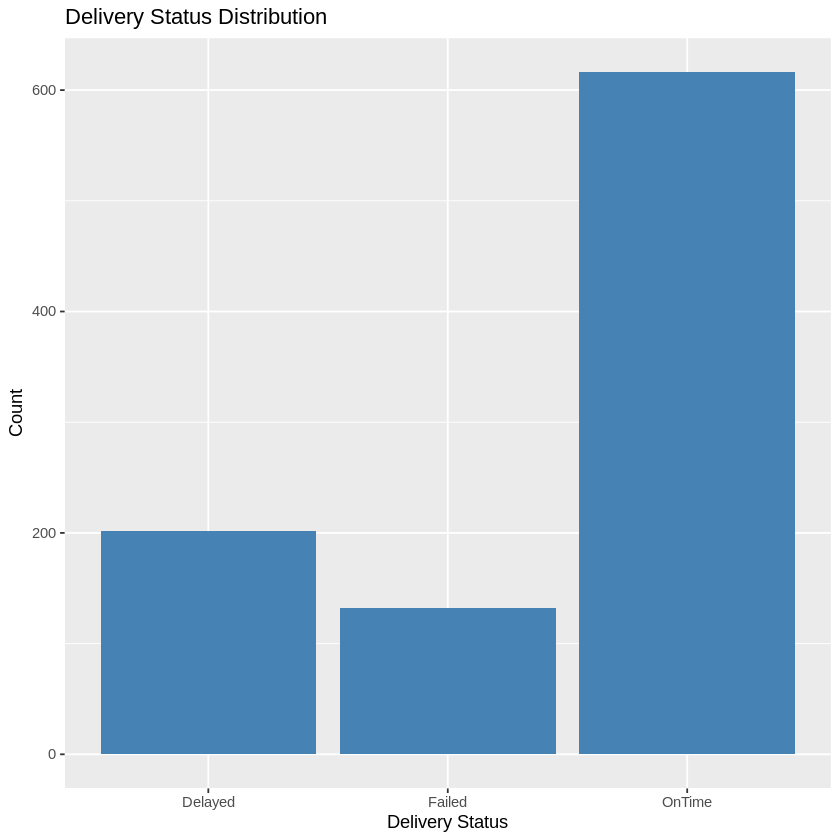

In [8]:
ggplot(deliveries, aes(x = delivery_status)) +
  geom_bar(fill = "steelblue") +
  labs(
    title = "Delivery Status Distribution",
    x = "Delivery Status",
    y = "Count"
  )

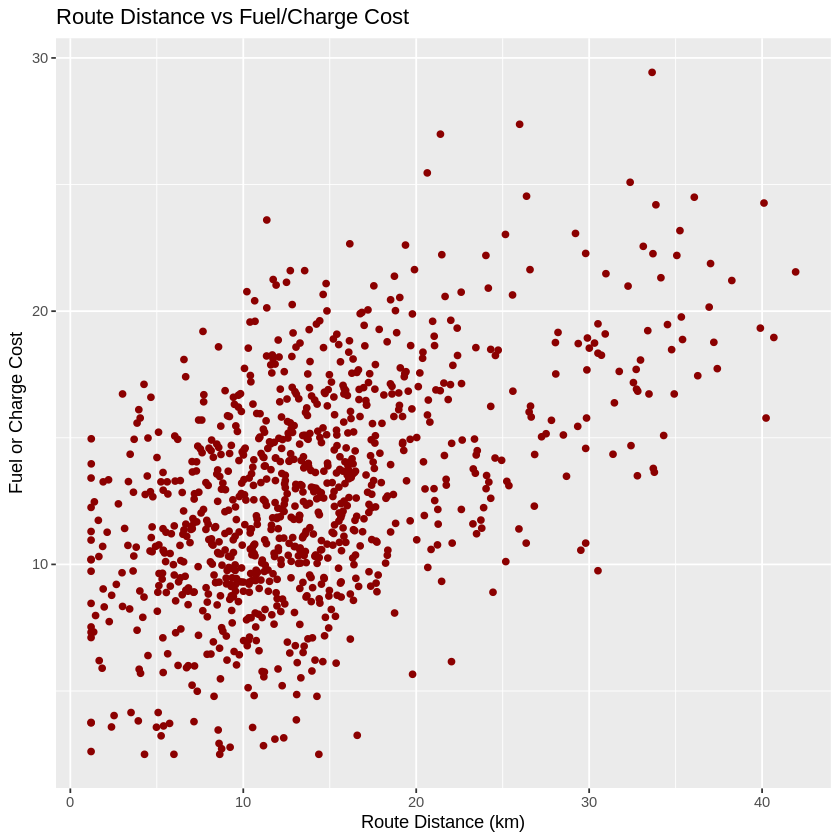

In [9]:
ggplot(
  deliveries,
  aes(
    x = route_distance_km,
    y = fuel_or_charge_cost
  )
) +
  geom_point(color = "darkred") +
  labs(
    title = "Route Distance vs Fuel/Charge Cost",
    x = "Route Distance (km)",
    y = "Fuel or Charge Cost"
  )

In [10]:
sqldf("
SELECT
    delivery_status,
    AVG(customer_rating_post_delivery) AS avg_rating
FROM deliveries
GROUP BY delivery_status
")

delivery_status,avg_rating
<chr>,<dbl>
Delayed,3.114975
Failed,3.049313
OnTime,4.283273
